# 01 - EDA Overview (Maximum-Detail)

This notebook performs a comprehensive exploratory analysis for the Telco Customer Churn dataset.

## Objectives
- Validate data quality and schema assumptions.
- Quantify churn imbalance and segment-level risk.
- Study numerical and categorical feature behavior vs churn.
- Produce publication-ready visuals for model strategy decisions.

## Expected Output
A detailed EDA package with quality checks, core distributions, churn drivers, and practical recommendations for preprocessing and modeling.

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

DATA_PATH = '../data/raw/telco.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df_raw.shape}')
display(df_raw.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) Data Snapshot and Schema Audit

We begin with structural validation: data types, cardinality, duplicates, and quick profile statistics.

In [14]:
# Basic structure
print('Rows:', df_raw.shape[0])
print('Columns:', df_raw.shape[1])

schema_df = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': df_raw.dtypes.astype(str).values,
    'n_unique': [df_raw[c].nunique(dropna=False) for c in df_raw.columns],
    'missing_count': [df_raw[c].isna().sum() for c in df_raw.columns],
    'missing_rate_%': [round(df_raw[c].isna().mean() * 100, 3) for c in df_raw.columns],
})
display(schema_df)

# Duplicate and ID checks
row_duplicates = df_raw.duplicated().sum()
id_duplicates = df_raw['customerID'].duplicated().sum() if 'customerID' in df_raw.columns else np.nan
print(f'Exact duplicate rows: {row_duplicates}')
print(f'Duplicate customerID count: {id_duplicates}')

Rows: 7043
Columns: 21


,column,dtype,n_unique,missing_count,missing_rate_%
0,customerID,str,7043,0,0.0
1,gender,str,2,0,0.0
2,SeniorCitizen,int64,2,0,0.0
3,Partner,str,2,0,0.0
4,Dependents,str,2,0,0.0
5,tenure,int64,73,0,0.0
6,PhoneService,str,2,0,0.0
7,MultipleLines,str,3,0,0.0
8,InternetService,str,3,0,0.0
9,OnlineSecurity,str,3,0,0.0


Exact duplicate rows: 0
Duplicate customerID count: 0


## 2) Data Cleaning Pre-Check: `TotalCharges`

`TotalCharges` is commonly loaded as object due to blank-string values in this dataset.

We quantify coercion-induced missing values and verify the relationship with early-tenure customers.

In [15]:
df = df_raw.copy()

# Convert TotalCharges safely
if 'TotalCharges' in df.columns:
    df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    missing_totalcharges = df['TotalCharges_num'].isna().sum()
    print(f'Missing after numeric coercion (TotalCharges): {missing_totalcharges}')

    # Investigate these rows
    tc_missing_rows = df[df['TotalCharges_num'].isna()].copy()
    display(tc_missing_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(15))

    if not tc_missing_rows.empty:
        print('Tenure distribution for TotalCharges missing rows:')
        display(tc_missing_rows['tenure'].value_counts(dropna=False).sort_index())

Missing after numeric coercion (TotalCharges): 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Tenure distribution for TotalCharges missing rows:


tenure
0    11
Name: count, dtype: int64

## 3) Missingness and Target Imbalance

We visualize missingness and class distribution because these directly impact modeling strategy (metric selection, thresholding, and balancing).

,missing_count,missing_rate
TotalCharges_num,11,0.156183
customerID,0,0.000000
SeniorCitizen,0,0.000000
Partner,0,0.000000
Dependents,0,0.000000
gender,0,0.000000
tenure,0,0.000000
PhoneService,0,0.000000
InternetService,0,0.000000
MultipleLines,0,0.000000


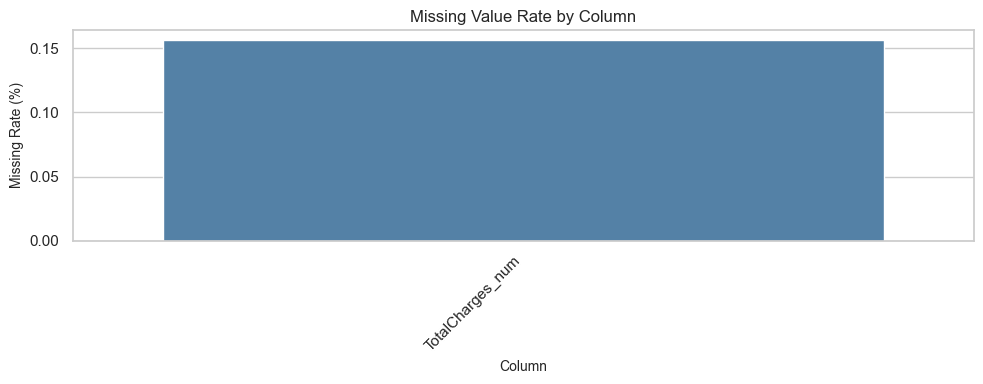

Churn rate: 26.54%


,Churn,count,ratio
0,No,5174,0.73463
1,Yes,1869,0.26537


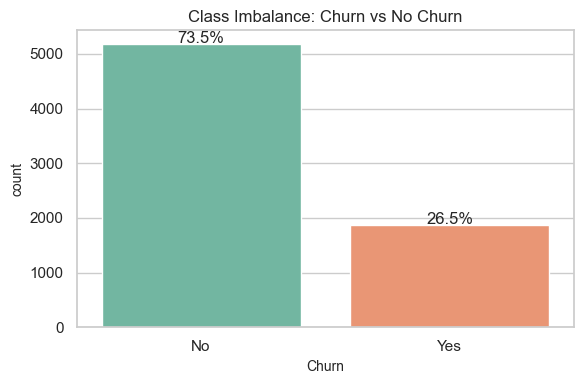

In [16]:
# Missingness profile
missing_profile = (
    df.isna().sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_rate=lambda x: x['missing_count'] / len(df) * 100)
    .sort_values('missing_count', ascending=False)
)
display(missing_profile)

plt.figure(figsize=(10, 4))
missing_non_zero = missing_profile[missing_profile['missing_count'] > 0]
if missing_non_zero.empty:
    plt.text(0.5, 0.5, 'No NaN values detected in raw frame\n(object blanks may still exist)', ha='center', va='center')
    plt.axis('off')
else:
    sns.barplot(data=missing_non_zero.reset_index(), x='index', y='missing_rate', color='steelblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Missing Rate (%)')
    plt.xlabel('Column')
    plt.title('Missing Value Rate by Column')
plt.tight_layout()
plt.show()

# Target distribution
churn_counts = df['Churn'].value_counts(dropna=False)
churn_rate = churn_counts.get('Yes', 0) / len(df)
print(f'Churn rate: {churn_rate:.2%}')

tmp = churn_counts.rename_axis('Churn').reset_index(name='count')
tmp['ratio'] = tmp['count'] / tmp['count'].sum()

display(tmp)

plt.figure(figsize=(6, 4))
sns.barplot(data=tmp, x='Churn', y='count', palette='Set2')
for i, row in tmp.iterrows():
    plt.text(i, row['count'] + 20, f"{row['ratio']:.1%}", ha='center')
plt.title('Class Imbalance: Churn vs No Churn')
plt.tight_layout()
plt.show()

## 4) Numerical Feature Analysis

We inspect central tendency, spread, outliers, and class-conditional distributions for key numerical variables.

Columns included: `tenure`, `MonthlyCharges`, and cleaned `TotalCharges_num`.

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges_num,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


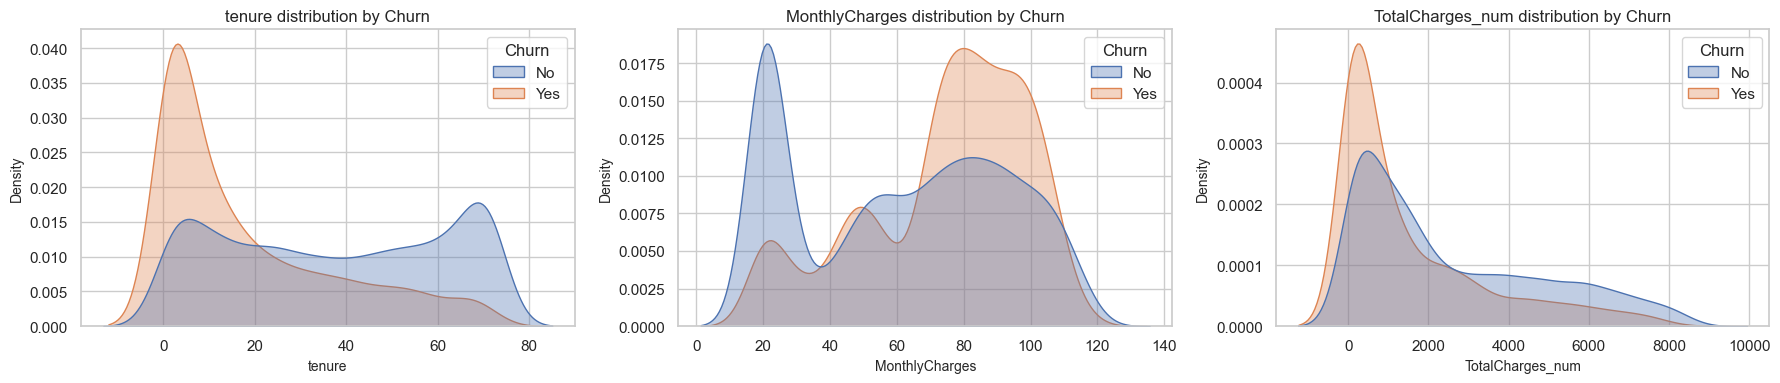

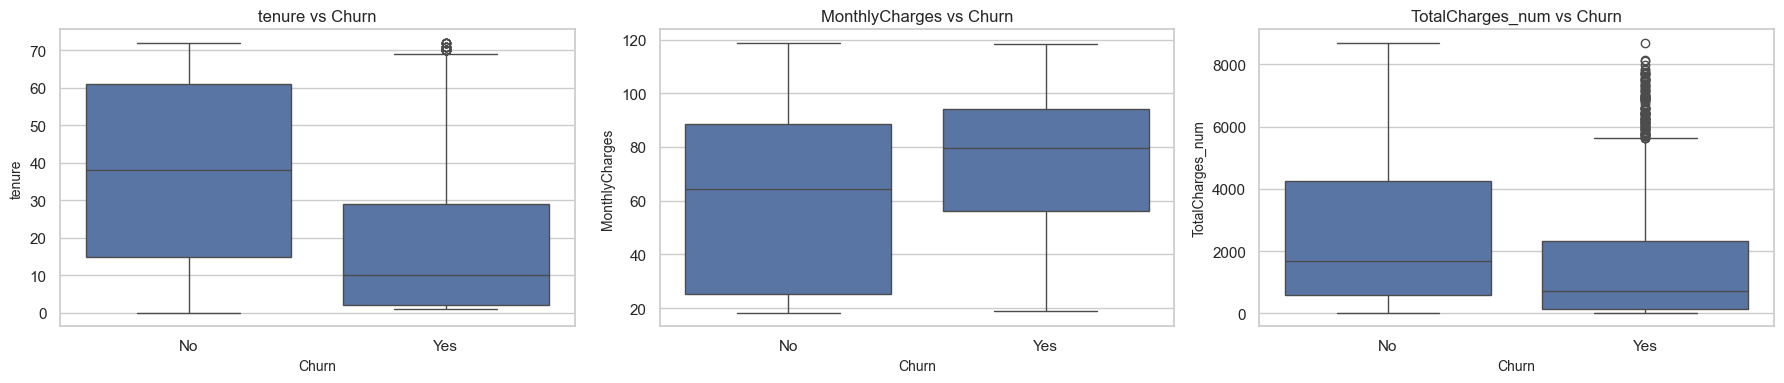

In [17]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_num']
num_df = df[numeric_cols + ['Churn']].copy()

display(num_df[numeric_cols].describe().T)

# Distribution by churn status
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=num_df, x=col, hue='Churn', fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(f'{col} distribution by Churn')
plt.tight_layout()
plt.show()

# Boxplots for outlier perspective
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=num_df, x='Churn', y=col, ax=ax)
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

## 5) Categorical Feature Risk Profiling

For each major categorical variable, we calculate and visualize churn rate to identify high-risk categories.

This supports feature engineering and model interpretation decisions.

In [18]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

analysis_df = df.copy()
analysis_df['Churn_Flag'] = (analysis_df['Churn'] == 'Yes').astype(int)

risk_tables = {}
for col in categorical_cols:
    grp = (
        analysis_df.groupby(col, dropna=False)
        .agg(customers=('Churn_Flag', 'size'), churn_rate=('Churn_Flag', 'mean'))
        .reset_index()
        .sort_values('churn_rate', ascending=False)
    )
    grp['churn_rate_pct'] = (grp['churn_rate'] * 100).round(2)
    risk_tables[col] = grp

# Show top risk tables for key variables
for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']:
    print(f'\n=== {col} ===')
    display(risk_tables[col])


=== Contract ===


,Contract,customers,churn_rate,churn_rate_pct
0,Month-to-month,3875,0.427097,42.71
1,One year,1473,0.112695,11.27
2,Two year,1695,0.028319,2.83



=== InternetService ===


,InternetService,customers,churn_rate,churn_rate_pct
1,Fiber optic,3096,0.418928,41.89
0,DSL,2421,0.189591,18.96
2,No,1526,0.074050,7.40



=== PaymentMethod ===


,PaymentMethod,customers,churn_rate,churn_rate_pct
2,Electronic check,2365,0.452854,45.29
3,Mailed check,1612,0.191067,19.11
0,Bank transfer (automatic),1544,0.167098,16.71
1,Credit card (automatic),1522,0.152431,15.24



=== TechSupport ===


,TechSupport,customers,churn_rate,churn_rate_pct
0,No,3473,0.416355,41.64
2,Yes,2044,0.151663,15.17
1,No internet service,1526,0.074050,7.40


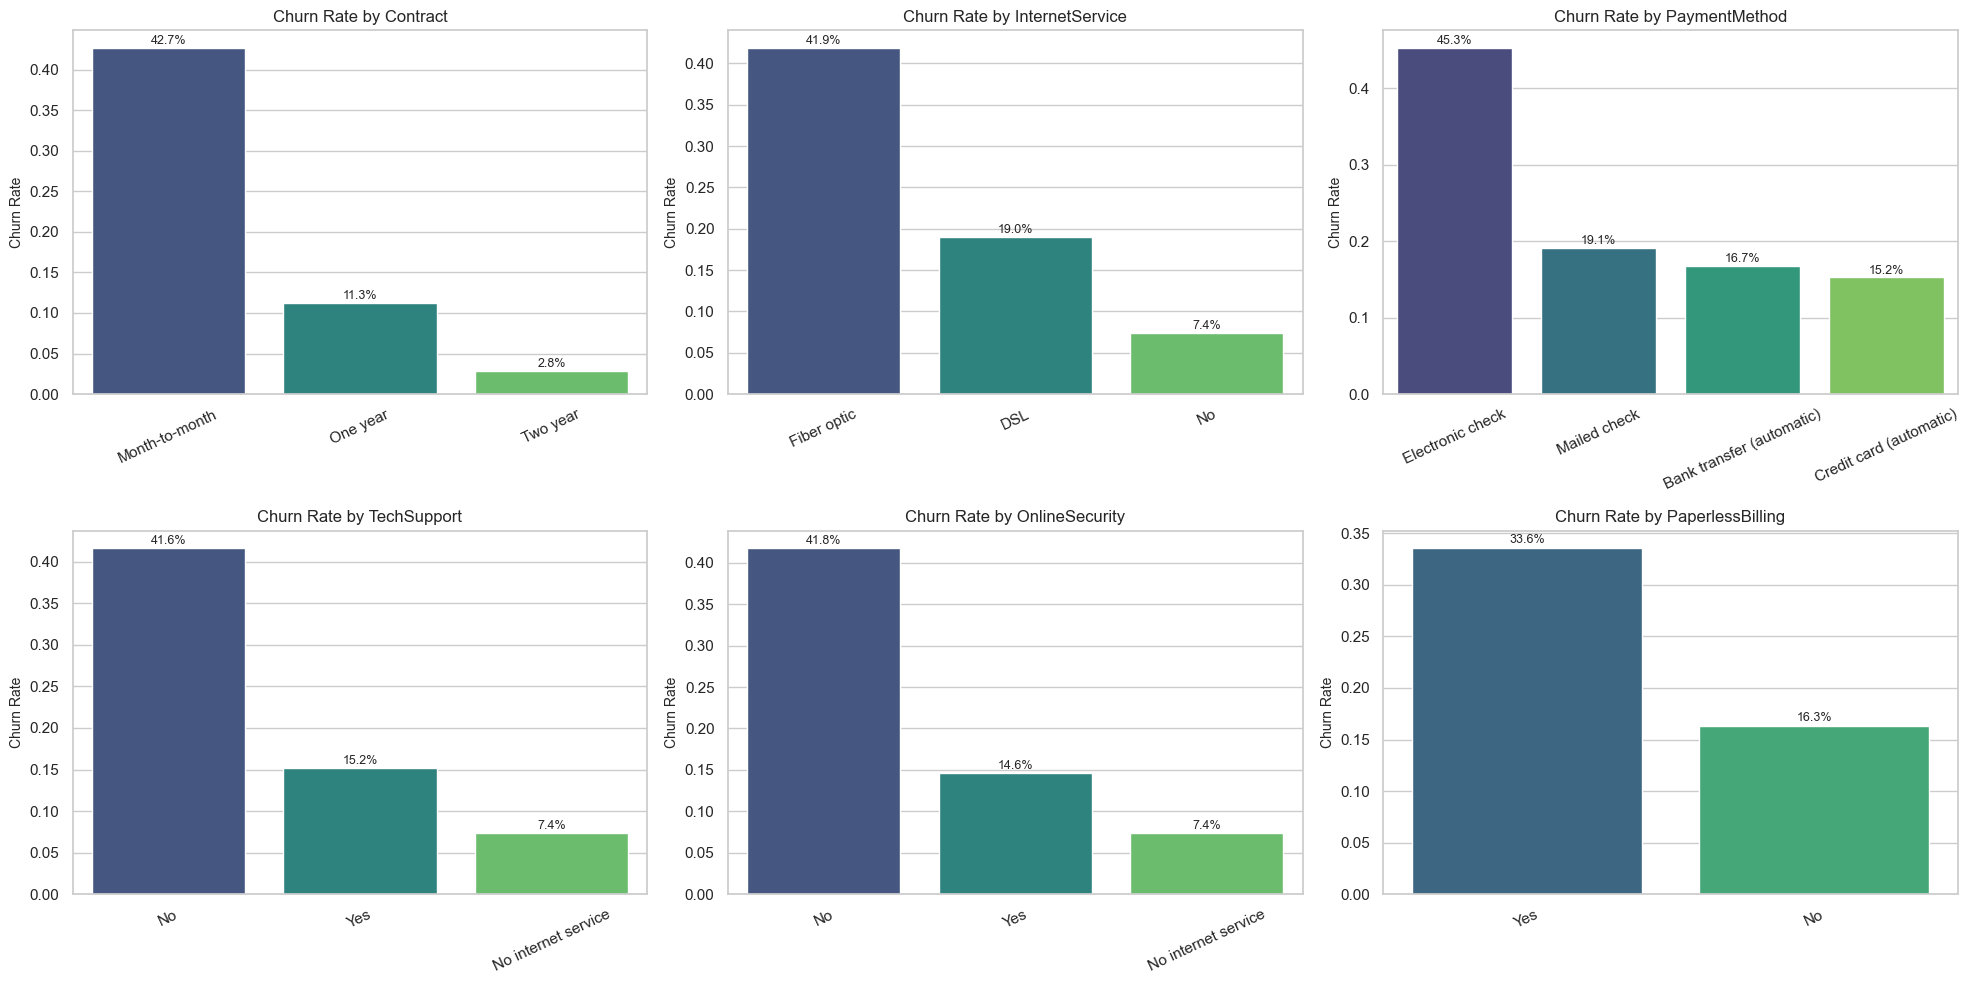

In [19]:
# Multi-panel churn-rate visualization for categorical drivers
plot_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    plot_df = risk_tables[col].copy().sort_values('churn_rate', ascending=False)
    sns.barplot(data=plot_df, x=col, y='churn_rate', ax=ax, palette='viridis')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    for patch, val in zip(ax.patches, plot_df['churn_rate']):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 0.005,
            f'{val:.1%}',
            ha='center',
            fontsize=9,
        )

for ax in axes[len(plot_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6) Segment-Level Deep Dives

We examine combinations of business-critical attributes to reveal high-risk cohorts.

Focus segments:
- `Contract x InternetService`
- `Contract x PaymentMethod`
- `SeniorCitizen x Dependents x Partner`

,Contract,InternetService,churn_rate,customers
1,Month-to-month,Fiber optic,0.546053,2128
0,Month-to-month,DSL,0.322159,1223
4,One year,Fiber optic,0.192950,539
2,Month-to-month,No,0.188931,524
3,One year,DSL,0.092982,570
7,Two year,Fiber optic,0.072261,429
5,One year,No,0.024725,364
6,Two year,DSL,0.019108,628
8,Two year,No,0.007837,638


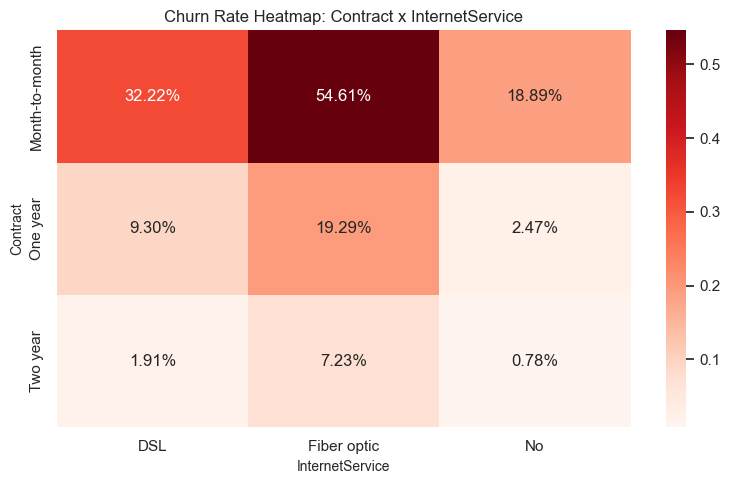

,Contract,PaymentMethod,churn_rate,customers
2,Month-to-month,Electronic check,0.537297,1850
0,Month-to-month,Bank transfer (automatic),0.341256,589
1,Month-to-month,Credit card (automatic),0.327808,543
3,Month-to-month,Mailed check,0.315789,893
6,One year,Electronic check,0.184438,347
5,One year,Credit card (automatic),0.103015,398
4,One year,Bank transfer (automatic),0.097187,391
10,Two year,Electronic check,0.077381,168
7,One year,Mailed check,0.068249,337
8,Two year,Bank transfer (automatic),0.033688,564


,SeniorCitizen,Partner,Dependents,churn_rate,customers
4,1,No,No,0.491979,561
6,1,Yes,No,0.363265,490
0,0,No,No,0.311512,2719
5,1,No,Yes,0.250000,8
7,1,Yes,Yes,0.240964,83
1,0,No,Yes,0.212465,353
2,0,Yes,No,0.208083,1163
3,0,Yes,Yes,0.137455,1666


In [20]:
segment_contract_internet = (
    analysis_df.groupby(['Contract', 'InternetService'])['Churn_Flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .sort_values('churn_rate', ascending=False)
)

display(segment_contract_internet.head(15))

pivot_ci = segment_contract_internet.pivot(index='Contract', columns='InternetService', values='churn_rate')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_ci, annot=True, fmt='.2%', cmap='Reds')
plt.title('Churn Rate Heatmap: Contract x InternetService')
plt.tight_layout()
plt.show()

segment_contract_pay = (
    analysis_df.groupby(['Contract', 'PaymentMethod'])['Churn_Flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .sort_values('churn_rate', ascending=False)
)
display(segment_contract_pay.head(15))

segment_senior_family = (
    analysis_df.groupby(['SeniorCitizen', 'Partner', 'Dependents'])['Churn_Flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .sort_values('churn_rate', ascending=False)
)
display(segment_senior_family.head(15))

## 7) Correlation and Engineered Numeric Perspectives

We build core engineered features used later in modeling and inspect their behavior in relation to churn risk.

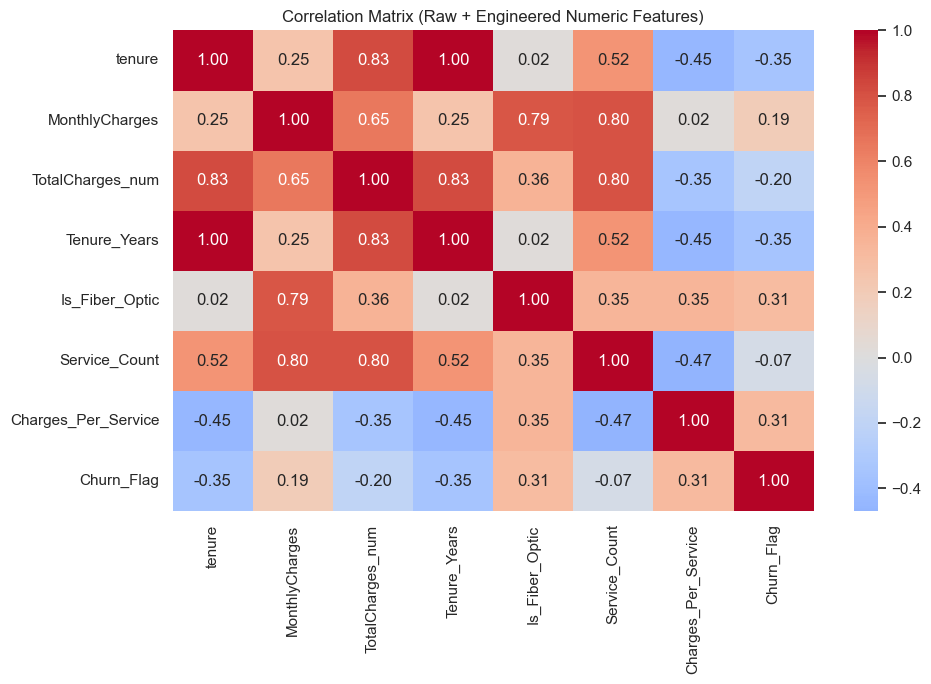

,churn_rate,customers
Charges_Per_Service,,
"(10.416, 15.7]",0.074263,1764
"(15.7, 19.75]",0.213477,1766
"(19.75, 24.525]",0.275528,1753
"(24.525, 72.25]",0.498864,1760


In [21]:
# Lightweight engineered features for EDA perspective
eda_feat = analysis_df.copy()
eda_feat['Tenure_Years'] = eda_feat['tenure'] / 12.0
eda_feat['Is_Fiber_Optic'] = (eda_feat['InternetService'] == 'Fiber optic').astype(int)

service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

def to_service_flag(s):
    return s.astype(str).str.lower().isin(['yes', 'dsl', 'fiber optic']).astype(int)

eda_feat['Service_Count'] = sum(to_service_flag(eda_feat[c]) for c in service_cols)
eda_feat['Charges_Per_Service'] = eda_feat['MonthlyCharges'] / np.maximum(eda_feat['Service_Count'], 1)

engineered_numeric = [
    'tenure', 'MonthlyCharges', 'TotalCharges_num',
    'Tenure_Years', 'Is_Fiber_Optic', 'Service_Count', 'Charges_Per_Service', 'Churn_Flag'
]

corr = eda_feat[engineered_numeric].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Raw + Engineered Numeric Features)')
plt.tight_layout()
plt.show()

display(
    eda_feat.groupby(pd.qcut(eda_feat['Charges_Per_Service'], 4, duplicates='drop'))['Churn_Flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
)

## 8) Stage-1 Findings Recap (Interim Checkpoint)

This is an **interim recap** of insights gathered from Sections 1–7 (data quality, univariate distributions, categorical risk profiling, segment-level views, and engineered numerics).

It is **not** the final synthesis. Sections 9–20 add deeper analysis:
- Formal statistical testing (Chi-square, Cramer's V, Mann-Whitney U)
- Tenure lifecycle and cohort analysis
- Service adoption and premium bundle effects
- Bivariate density and pairwise interactions
- Wilson 95% confidence intervals on churn rates
- Full categorical coverage (16 features)
- Outlier auditing with violins
- Business KPIs and revenue at risk
- Histogram grid, percentile tables
- Multi-feature high-risk combination mining

The **final synthesis with modeling implications** lives in **Section 21**.

### Stage-1 takeaways (from Sections 1–7)
1. **Data quality**: no row/ID duplicates; only `TotalCharges` needs coercion + median imputation (exactly 11 rows, all with `tenure == 0`).
2. **Class imbalance**: ~26.5% positives → track ROC-AUC and PR-AUC, not Accuracy.
3. **Top visual drivers**: `Contract`, `InternetService`, `PaymentMethod`, with `TechSupport` and `OnlineSecurity` as strong protective signals.
4. **Engineered features** (`Tenure_Years`, `Service_Count`, `Is_Fiber_Optic`, `Charges_Per_Service`) show meaningful correlation with churn — they are worth keeping in the modeling pipeline.

The cell below auto-generates a quick reference snapshot of the highest-risk categories observed in Sections 5–6.

In [22]:
# Stage-1 findings snapshot (auto-generated)
# Quick reference values from the univariate/segment analysis above.
# Deeper, statistically validated findings appear in Sections 9-21.
stage1_findings = {}

contract_risk = risk_tables['Contract'].sort_values('churn_rate', ascending=False)
stage1_findings['highest_risk_contract'] = contract_risk.iloc[0].to_dict()

payment_risk = risk_tables['PaymentMethod'].sort_values('churn_rate', ascending=False)
stage1_findings['highest_risk_payment'] = payment_risk.iloc[0].to_dict()

internet_risk = risk_tables['InternetService'].sort_values('churn_rate', ascending=False)
stage1_findings['highest_risk_internet'] = internet_risk.iloc[0].to_dict()

techsupport_risk = risk_tables['TechSupport'].sort_values('churn_rate', ascending=False)
stage1_findings['highest_risk_techsupport'] = techsupport_risk.iloc[0].to_dict()

print('Stage-1 Findings Snapshot (interim — see Section 21 for full synthesis)')
for key, value in stage1_findings.items():
    print(f'\n{key}')
    print(value)

Stage-1 Findings Snapshot (interim — see Section 21 for full synthesis)

highest_risk_contract
{'Contract': 'Month-to-month', 'customers': 3875, 'churn_rate': 0.4270967741935484, 'churn_rate_pct': 42.71}

highest_risk_payment
{'PaymentMethod': 'Electronic check', 'customers': 2365, 'churn_rate': 0.4528541226215645, 'churn_rate_pct': 45.29}

highest_risk_internet
{'InternetService': 'Fiber optic', 'customers': 3096, 'churn_rate': 0.4189276485788114, 'churn_rate_pct': 41.89}

highest_risk_techsupport
{'TechSupport': 'No', 'customers': 3473, 'churn_rate': 0.4163547365390153, 'churn_rate_pct': 41.64}


## 9) Statistical Significance Testing

We complement visual inspection with formal tests:

- **Chi-square + Cramer's V** for each categorical vs `Churn` (effect size and significance).
- **Mann-Whitney U** for numerical features vs `Churn` (distribution-free comparison of medians).

This separates statistically meaningful drivers from cosmetic differences.

,feature,chi2,dof,p_value,cramers_v,significant_5%
0,Contract,1184.597,2,5.863038e-258,0.4101,True
1,OnlineSecurity,849.999,2,2.661150e-185,0.3474,True
2,TechSupport,828.197,2,1.443084e-180,0.3429,True
3,InternetService,732.310,2,9.571788e-160,0.3225,True
4,PaymentMethod,648.142,3,3.682355e-140,0.3034,True
5,OnlineBackup,601.813,2,2.079759e-131,0.2923,True
6,DeviceProtection,558.419,2,5.505219e-122,0.2816,True
7,StreamingMovies,375.661,2,2.667757e-82,0.2310,True
8,StreamingTV,374.204,2,5.528994e-82,0.2305,True
9,PaperlessBilling,258.278,1,4.073355e-58,0.1915,True


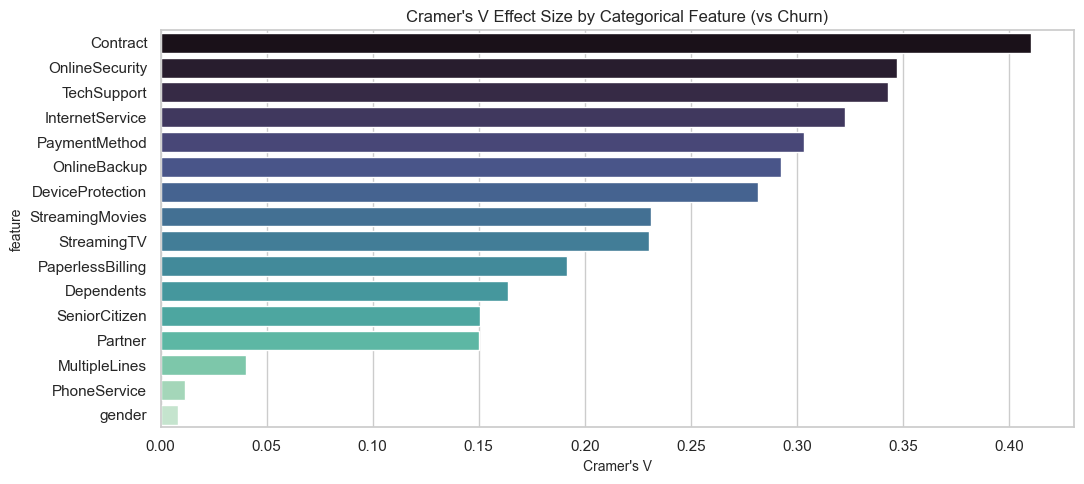

,feature,U_stat,p_value,mean_churn,mean_stay,median_churn,median_stay,significant_5%
0,tenure,2515538.0,2.419636e-208,17.98,37.57,10.00,38.00,True
1,TotalCharges_num,3360665.0,1.995985e-84,1531.80,2555.34,703.55,1683.60,True
2,MonthlyCharges,6003125.5,3.311628e-54,74.44,61.27,79.65,64.43,True


In [24]:
from scipy import stats

cat_test_records = []
for col in categorical_cols:
    contingency = pd.crosstab(analysis_df[col], analysis_df['Churn'])
    chi2_stat, p_val, dof, _ = stats.chi2_contingency(contingency)
    n_total = contingency.values.sum()
    cramers_v = np.sqrt(chi2_stat / (n_total * max(min(contingency.shape) - 1, 1)))
    cat_test_records.append({
        'feature': col,
        'chi2': round(chi2_stat, 3),
        'dof': dof,
        'p_value': p_val,
        'cramers_v': round(cramers_v, 4),
        'significant_5%': p_val < 0.05,
    })

chi2_df = pd.DataFrame(cat_test_records).sort_values('cramers_v', ascending=False).reset_index(drop=True)
display(chi2_df)

plt.figure(figsize=(11, 5))
sns.barplot(data=chi2_df, x='cramers_v', y='feature', palette='mako')
plt.title("Cramer's V Effect Size by Categorical Feature (vs Churn)")
plt.xlabel("Cramer's V")
plt.tight_layout()
plt.show()

num_test_records = []
for col in ['tenure', 'MonthlyCharges', 'TotalCharges_num']:
    series = df[col].dropna()
    target_mask = (df.loc[series.index, 'Churn'] == 'Yes')
    u_stat, p_val = stats.mannwhitneyu(series[target_mask], series[~target_mask], alternative='two-sided')
    num_test_records.append({
        'feature': col,
        'U_stat': round(u_stat, 1),
        'p_value': p_val,
        'mean_churn': round(series[target_mask].mean(), 2),
        'mean_stay': round(series[~target_mask].mean(), 2),
        'median_churn': round(series[target_mask].median(), 2),
        'median_stay': round(series[~target_mask].median(), 2),
        'significant_5%': p_val < 0.05,
    })

mw_df = pd.DataFrame(num_test_records).sort_values('p_value').reset_index(drop=True)
display(mw_df)

## 10) Tenure Lifecycle and Cohort Analysis

Tenure is the strongest churn signal in telco. We bin customers into lifecycle cohorts and study churn rate plus customer mass per bucket. This reveals when retention efforts pay off and where customers are leaving fastest.

,tenure_bucket,churn_rate,customers
0,0-6m,0.529372,1481
1,7-12m,0.358865,705
2,13-24m,0.287109,1024
3,25-36m,0.216346,832
4,37-48m,0.190289,762
5,49-60m,0.144231,832
6,61-72m,0.066098,1407


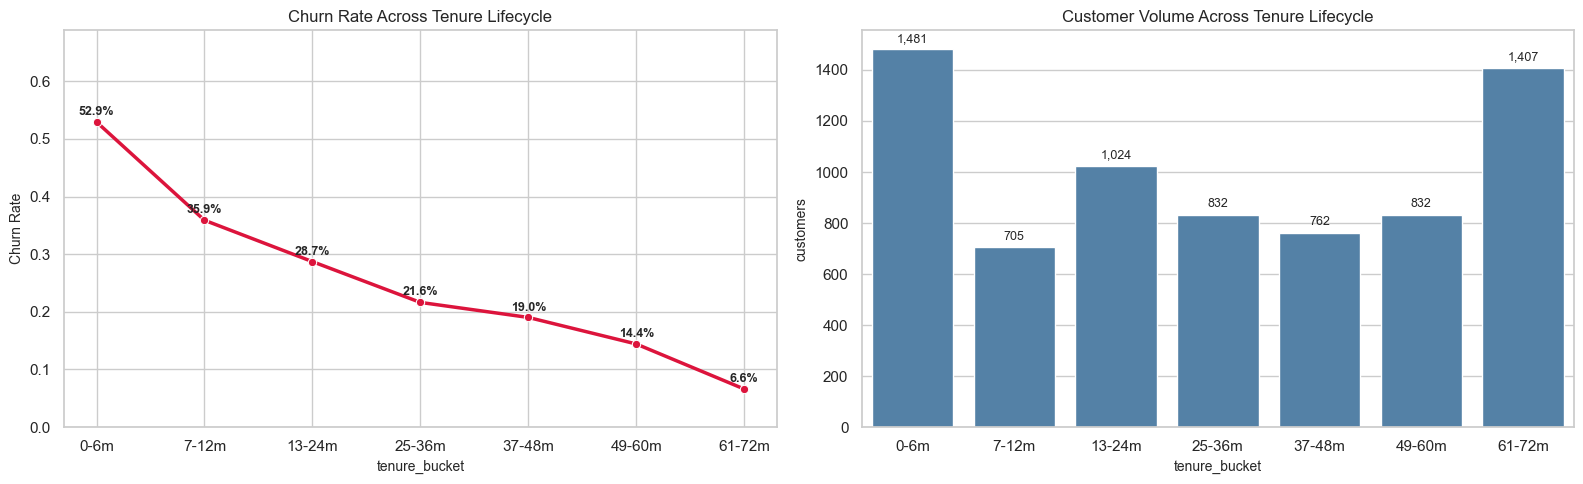

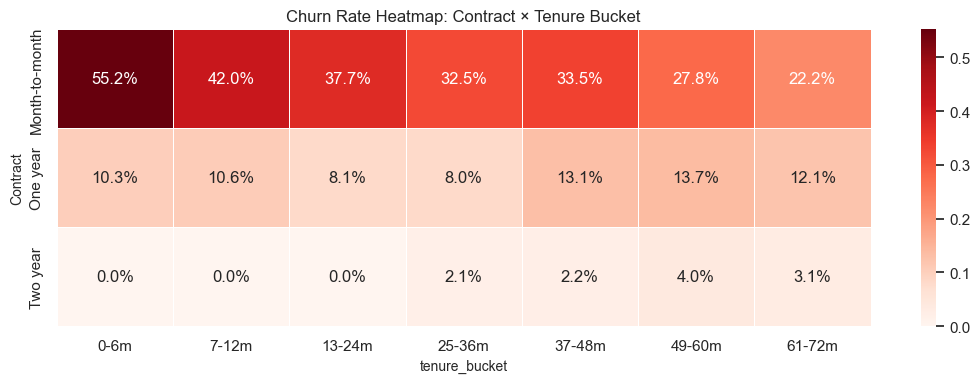

In [25]:
tenure_bins = [-0.1, 6, 12, 24, 36, 48, 60, 72]
tenure_labels = ['0-6m', '7-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m']
analysis_df['tenure_bucket'] = pd.cut(analysis_df['tenure'], bins=tenure_bins, labels=tenure_labels)

tenure_lifecycle = (
    analysis_df.groupby('tenure_bucket', observed=False)['Churn_Flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .reset_index()
)
display(tenure_lifecycle)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=tenure_lifecycle, x='tenure_bucket', y='churn_rate', marker='o',
             linewidth=2.5, color='crimson', ax=axes[0])
axes[0].set_title('Churn Rate Across Tenure Lifecycle')
axes[0].set_ylabel('Churn Rate')
for x_idx, y_val in enumerate(tenure_lifecycle['churn_rate']):
    axes[0].text(x_idx, y_val + 0.012, f'{y_val:.1%}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(tenure_lifecycle['churn_rate']) * 1.3)

sns.barplot(data=tenure_lifecycle, x='tenure_bucket', y='customers', ax=axes[1], color='steelblue')
axes[1].set_title('Customer Volume Across Tenure Lifecycle')
for x_idx, count in enumerate(tenure_lifecycle['customers']):
    axes[1].text(x_idx, count + 30, f'{count:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

pivot_contract_tenure = (
    analysis_df.groupby(['Contract', 'tenure_bucket'], observed=False)['Churn_Flag']
    .mean()
    .unstack()
)
plt.figure(figsize=(11, 4))
sns.heatmap(pivot_contract_tenure, annot=True, fmt='.1%', cmap='Reds', linewidths=0.4)
plt.title('Churn Rate Heatmap: Contract × Tenure Bucket')
plt.tight_layout()
plt.show()

## 11) Service Adoption Patterns and Premium Bundles

We measure how the **number of active services** and the **premium support bundle** depth interact with churn. Customers with deeper service relationships tend to be stickier.

,Service_Count,churn_rate,customers
0,0,0.437500,80
1,1,0.211052,1701
2,2,0.328283,1188
3,3,0.364767,965
4,4,0.313449,922
5,5,0.255507,908
6,6,0.224852,676
7,7,0.124051,395
8,8,0.052885,208


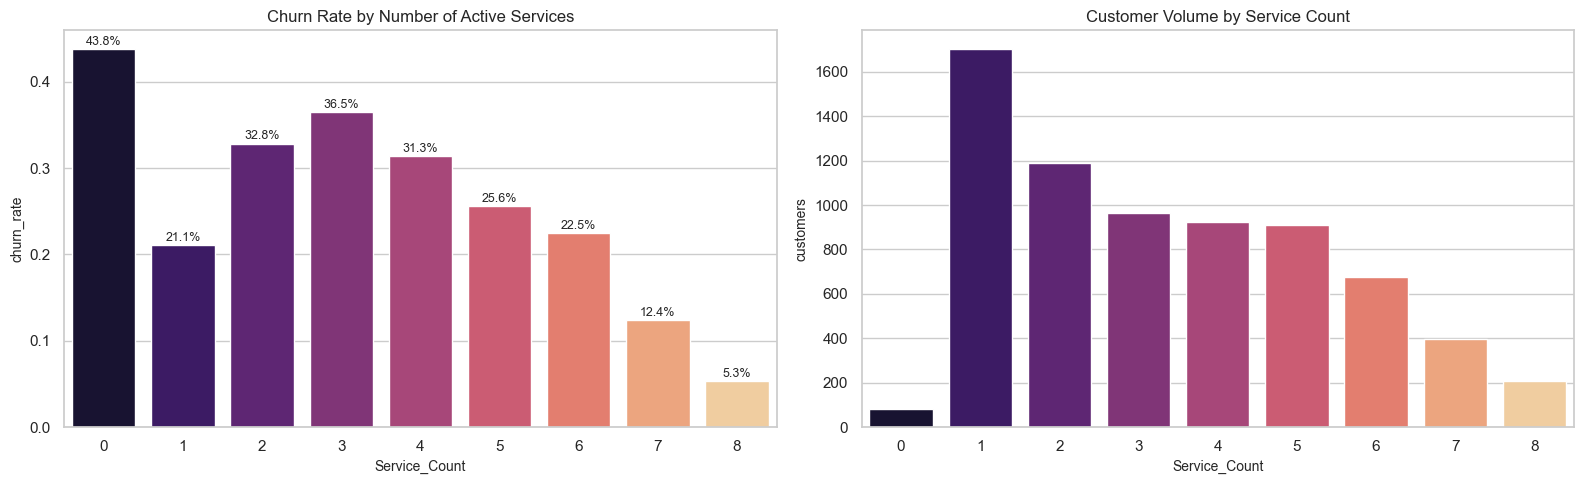

,Premium_Service_Count,churn_rate,customers
0,0,0.297530,2793
1,1,0.388548,1467
2,2,0.237609,1372
3,3,0.124336,941
4,4,0.053191,470


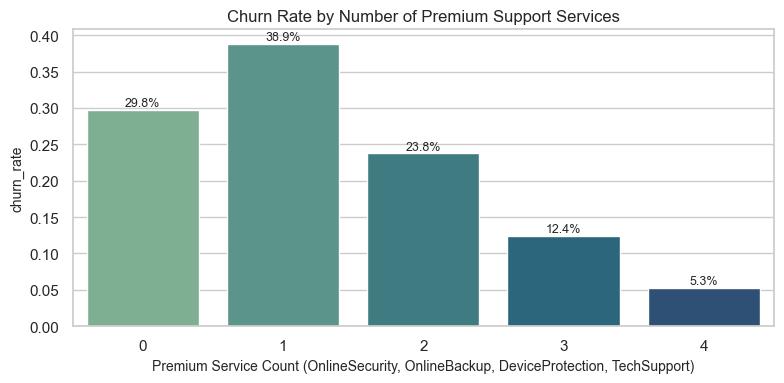

In [26]:
service_count_summary = (
    eda_feat.groupby('Service_Count')['Churn_Flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .reset_index()
)
display(service_count_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=service_count_summary, x='Service_Count', y='churn_rate', ax=axes[0], palette='magma')
axes[0].set_title('Churn Rate by Number of Active Services')
for i, val in enumerate(service_count_summary['churn_rate']):
    axes[0].text(i, val + 0.005, f'{val:.1%}', ha='center', fontsize=9)
sns.barplot(data=service_count_summary, x='Service_Count', y='customers', ax=axes[1], palette='magma')
axes[1].set_title('Customer Volume by Service Count')
plt.tight_layout()
plt.show()

premium_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
premium_count = sum((analysis_df[c] == 'Yes').astype(int) for c in premium_cols)
analysis_df['Premium_Service_Count'] = premium_count

premium_summary = (
    analysis_df.groupby('Premium_Service_Count')['Churn_Flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .reset_index()
)
display(premium_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=premium_summary, x='Premium_Service_Count', y='churn_rate', palette='crest')
for i, val in enumerate(premium_summary['churn_rate']):
    plt.text(i, val + 0.005, f'{val:.1%}', ha='center', fontsize=9)
plt.title('Churn Rate by Number of Premium Support Services')
plt.xlabel('Premium Service Count (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport)')
plt.tight_layout()
plt.show()

## 12) Bivariate Density and Pairwise Interactions

`tenure` and `MonthlyCharges` interact strongly: high charges with low tenure is the canonical churner profile. We visualize:

- Hexbin density of all customers
- 2D KDE separated by churn class
- Sampled scatter for direct comparison

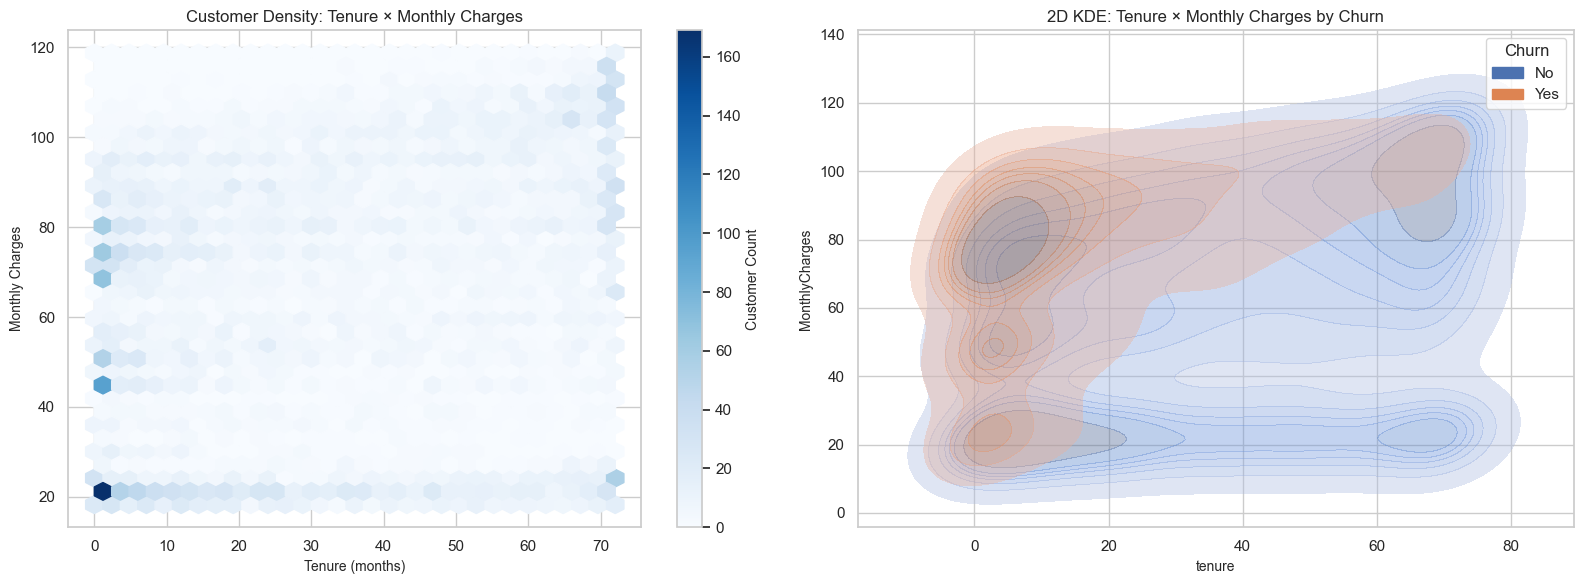

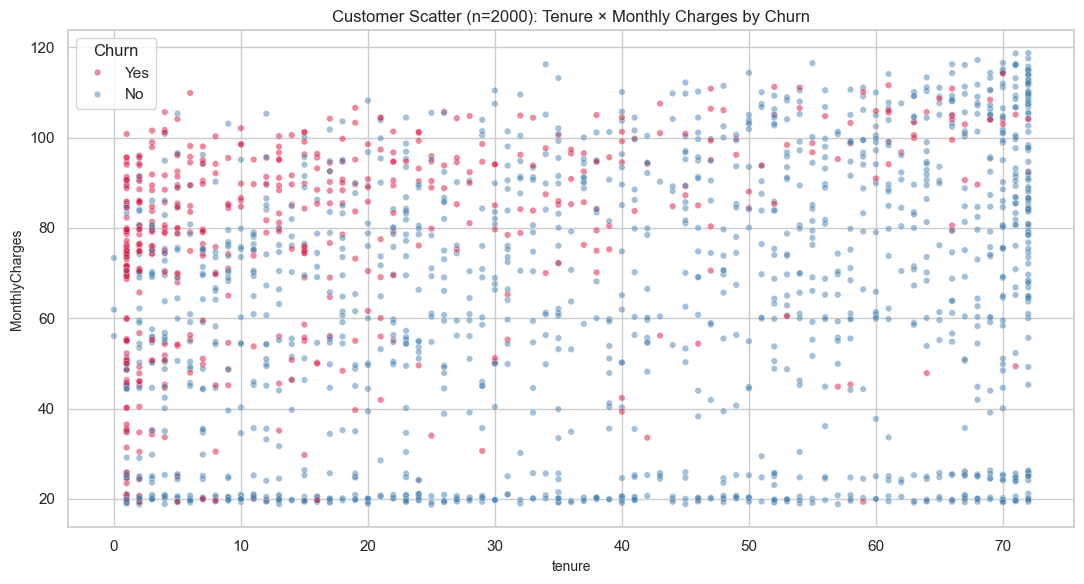

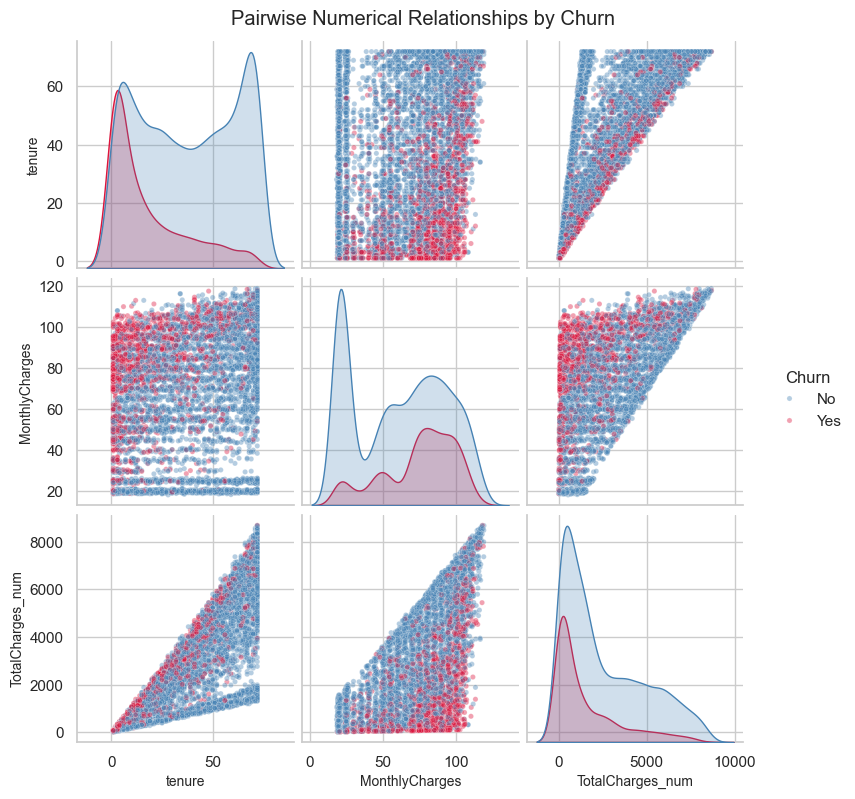

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hb = axes[0].hexbin(df['tenure'], df['MonthlyCharges'], gridsize=30, cmap='Blues')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly Charges')
axes[0].set_title('Customer Density: Tenure × Monthly Charges')
plt.colorbar(hb, ax=axes[0], label='Customer Count')

sns.kdeplot(
    data=analysis_df, x='tenure', y='MonthlyCharges',
    hue='Churn', fill=True, alpha=0.4, thresh=0.05, levels=8, ax=axes[1]
)
axes[1].set_title('2D KDE: Tenure × Monthly Charges by Churn')
plt.tight_layout()
plt.show()

sample_size = min(2000, len(analysis_df))
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=analysis_df.sample(sample_size, random_state=42),
    x='tenure', y='MonthlyCharges', hue='Churn',
    alpha=0.5, s=22, palette={'Yes': 'crimson', 'No': 'steelblue'}
)
plt.title(f'Customer Scatter (n={sample_size}): Tenure × Monthly Charges by Churn')
plt.tight_layout()
plt.show()

pair_df = df[['tenure', 'MonthlyCharges', 'TotalCharges_num', 'Churn']].dropna()
sns.pairplot(pair_df, hue='Churn', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 14},
             palette={'Yes': 'crimson', 'No': 'steelblue'}, height=2.6)
plt.suptitle('Pairwise Numerical Relationships by Churn', y=1.02)
plt.show()

## 13) Churn Rates with 95% Wilson Confidence Intervals

A churn rate of 30% from 50 customers is far weaker evidence than 30% from 5,000.

We add **Wilson 95% CIs** on rate bars to distinguish robust signal from sampling noise. This was an explicit plan requirement.

,feature,category,churn_rate,lower,upper,n
0,Contract,Month-to-month,0.427097,0.411602,0.442736,3875
1,Contract,One year,0.112695,0.097543,0.129862,1473
2,Contract,Two year,0.028319,0.021425,0.037345,1695
8,InternetService,Fiber optic,0.418928,0.401659,0.436397,3096
7,InternetService,DSL,0.189591,0.174473,0.205692,2421
9,InternetService,No,0.074050,0.061954,0.088285,1526
13,OnlineSecurity,No,0.417667,0.401423,0.434092,3498
15,OnlineSecurity,Yes,0.146112,0.131377,0.162192,2019
14,OnlineSecurity,No internet service,0.074050,0.061954,0.088285,1526
17,PaperlessBilling,Yes,0.335651,0.321477,0.350127,4171


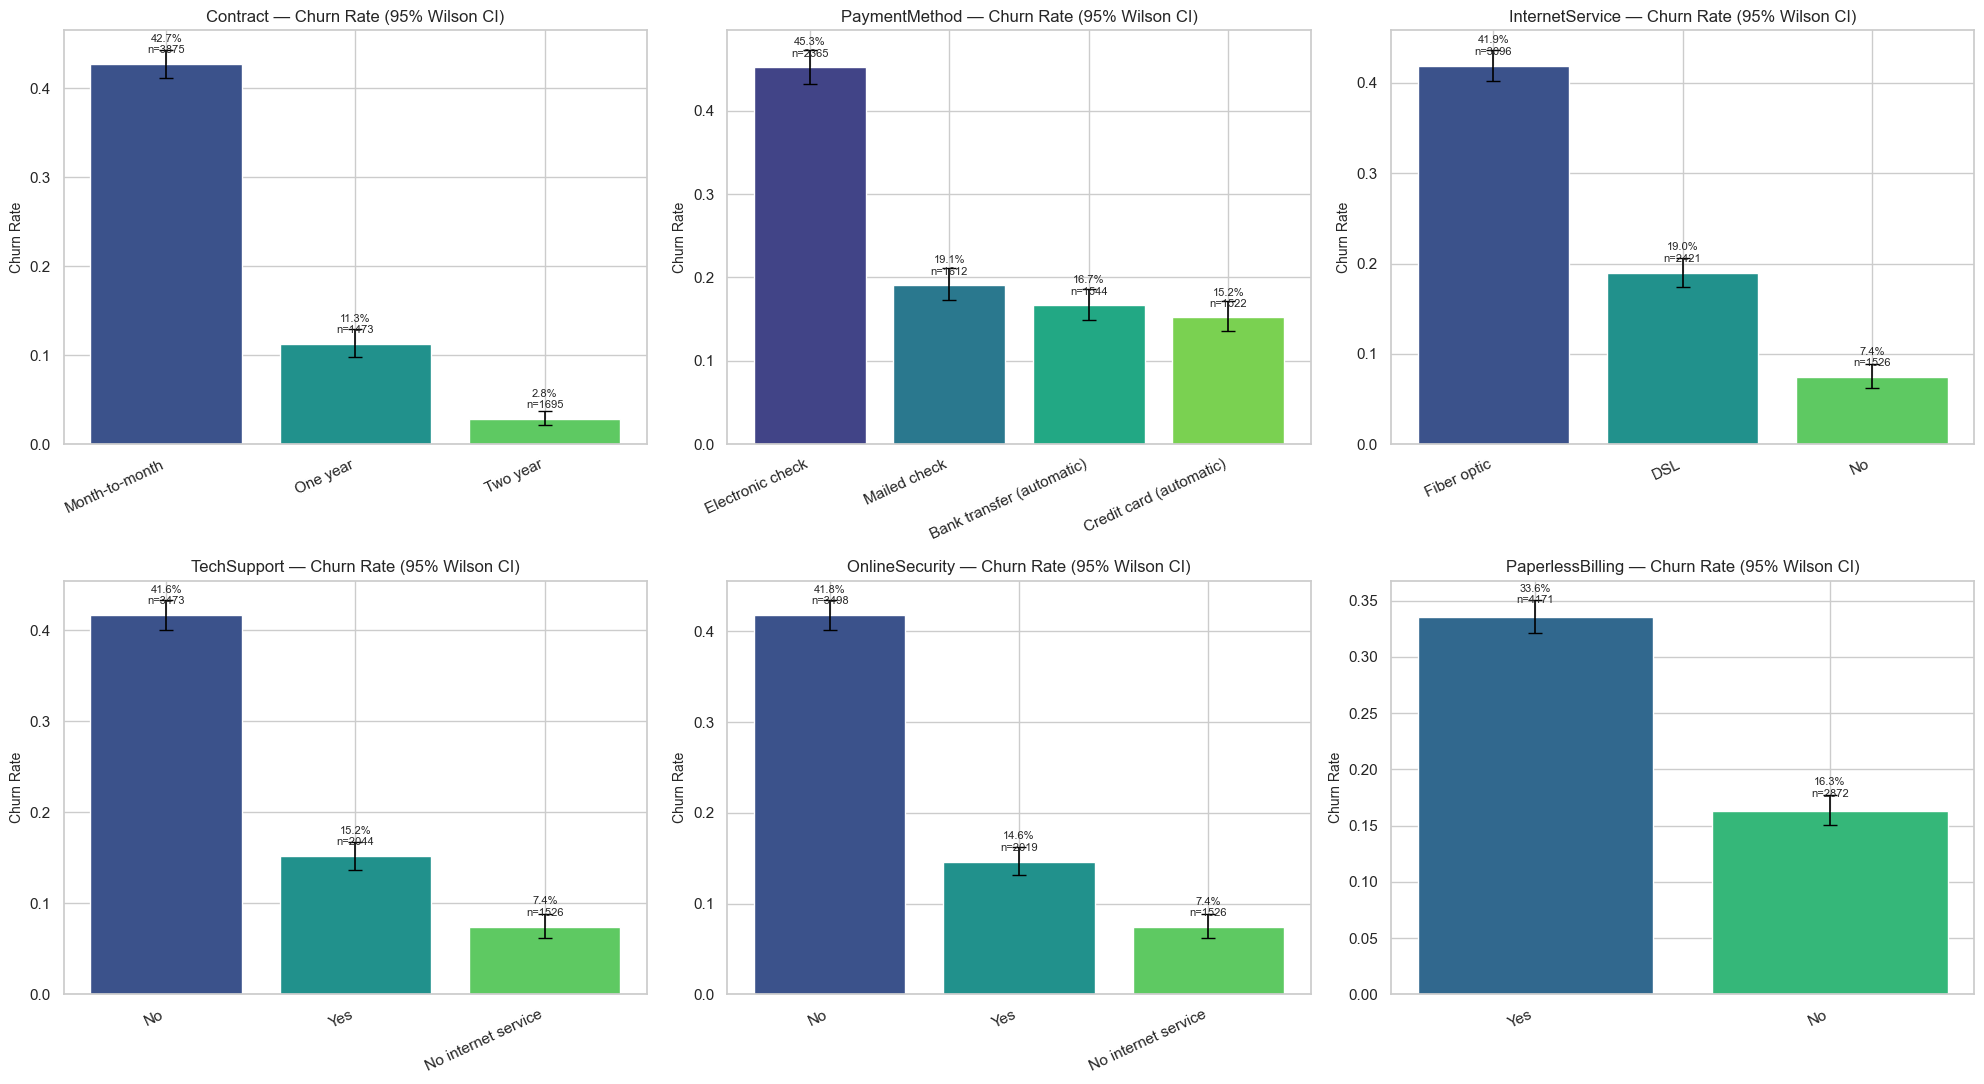

In [28]:
def wilson_ci(p, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (center - half, center + half)

ci_records = []
ci_features = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity', 'PaperlessBilling']
for col in ci_features:
    grp = analysis_df.groupby(col)['Churn_Flag'].agg(['mean', 'count']).reset_index()
    for _, row in grp.iterrows():
        lo, hi = wilson_ci(row['mean'], row['count'])
        ci_records.append({
            'feature': col,
            'category': row[col],
            'churn_rate': row['mean'],
            'lower': lo,
            'upper': hi,
            'n': int(row['count']),
        })

ci_df = pd.DataFrame(ci_records)
display(ci_df.sort_values(['feature', 'churn_rate'], ascending=[True, False]))

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for ax, col in zip(axes, ci_features):
    sub = ci_df[ci_df['feature'] == col].sort_values('churn_rate', ascending=False).reset_index(drop=True)
    ax.bar(range(len(sub)), sub['churn_rate'], color=sns.color_palette('viridis', len(sub)))
    ax.errorbar(
        range(len(sub)),
        sub['churn_rate'],
        yerr=[sub['churn_rate'] - sub['lower'], sub['upper'] - sub['churn_rate']],
        fmt='none', color='black', capsize=5, linewidth=1.2,
    )
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['category'], rotation=25, ha='right')
    ax.set_title(f'{col} — Churn Rate (95% Wilson CI)')
    ax.set_ylabel('Churn Rate')
    for i, (rate, n) in enumerate(zip(sub['churn_rate'], sub['n'])):
        ax.text(i, rate + 0.012, f'{rate:.1%}\nn={n}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 14) Full Categorical Coverage (16 features)

Section 5 covered the top drivers; here we show **every categorical feature** in one grid for completeness, with churn rate and sample size annotations.

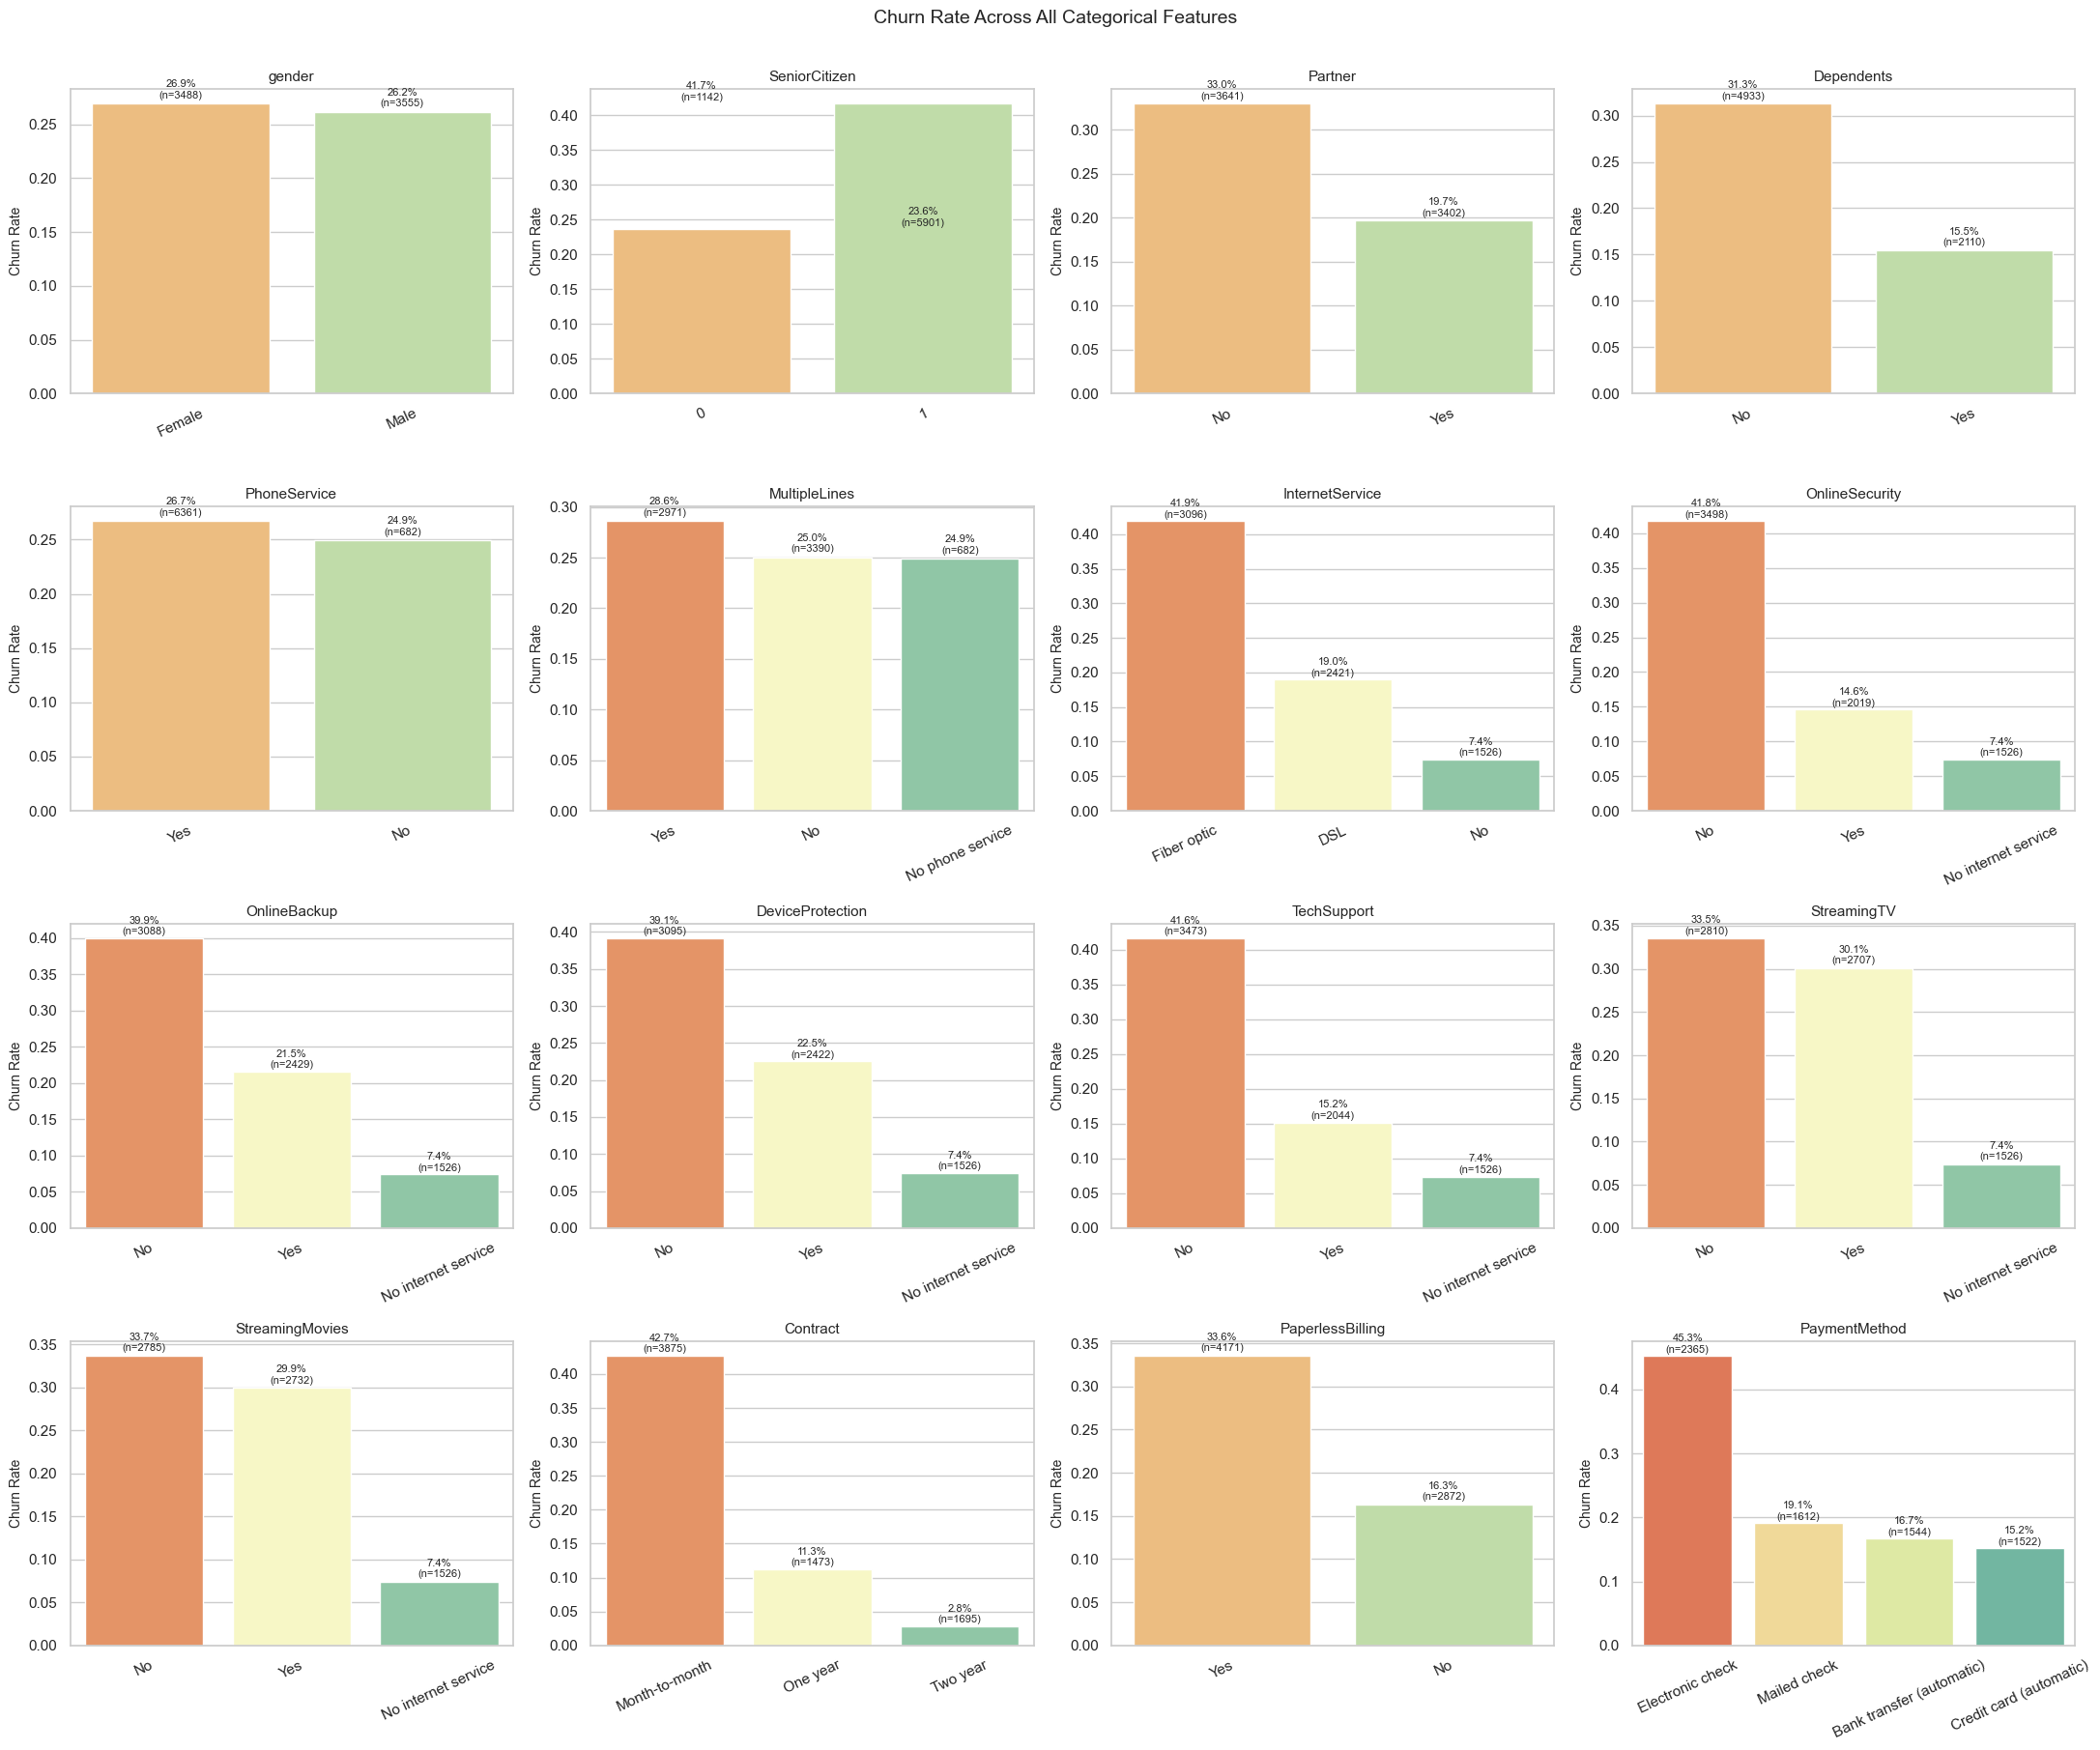

In [29]:
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    grp = (
        analysis_df.groupby(col)['Churn_Flag']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'rate', 'count': 'n'})
        .reset_index()
        .sort_values('rate', ascending=False)
    )
    sns.barplot(data=grp, x=col, y='rate', ax=ax, palette='Spectral')
    ax.set_title(f'{col}', fontsize=11)
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    for i, (rate, n) in enumerate(zip(grp['rate'], grp['n'])):
        ax.text(i, rate + 0.005, f'{rate:.1%}\n(n={int(n)})', ha='center', fontsize=8)

plt.suptitle('Churn Rate Across All Categorical Features', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

## 15) Outlier Audit (IQR + Violin Plots)

Formal outlier detection with the IQR rule plus violin plots that reveal distribution shape (multimodality, skew) per churn class — beyond what boxplots show.

,feature,q1,q3,iqr,lower_fence,upper_fence,outliers,outlier_rate_%
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0,0.0
2,TotalCharges_num,401.45,3794.74,3393.29,-4688.48,8884.67,0,0.0


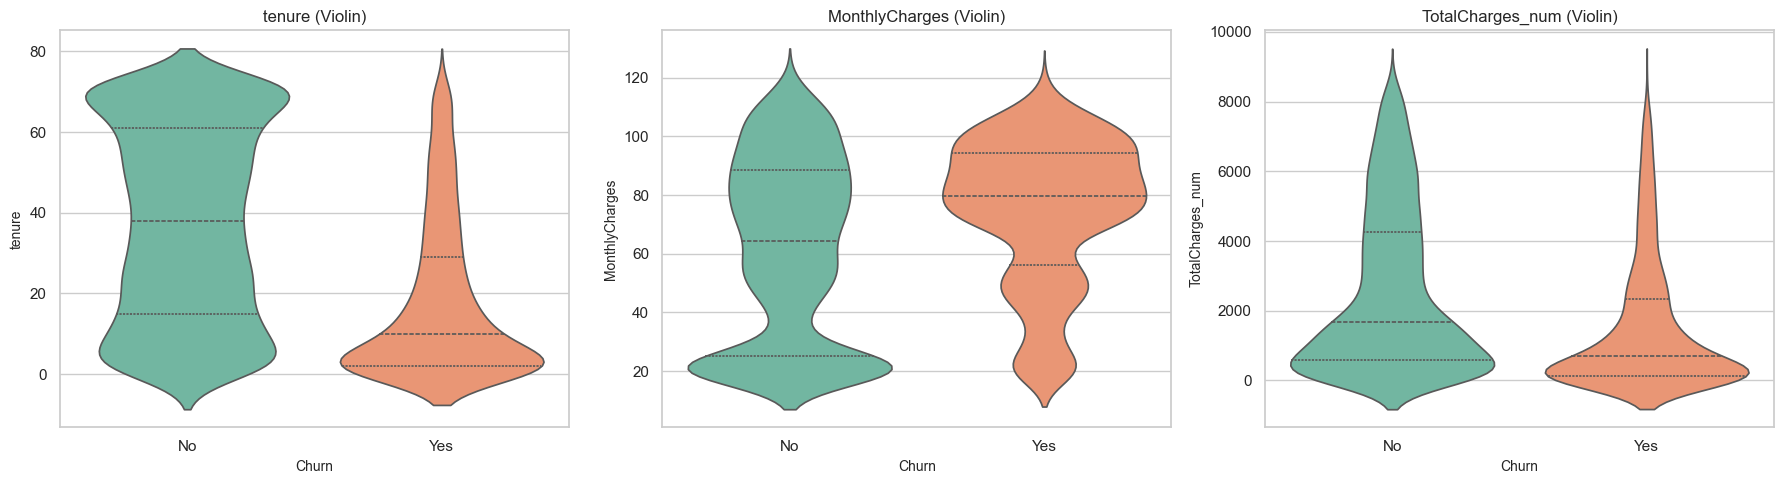

In [30]:
def iqr_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return {
        'q1': round(q1, 2),
        'q3': round(q3, 2),
        'iqr': round(iqr, 2),
        'lower_fence': round(lower, 2),
        'upper_fence': round(upper, 2),
        'outliers': int(mask.sum()),
        'outlier_rate_%': round(mask.mean() * 100, 3),
    }

audit_records = []
for col in ['tenure', 'MonthlyCharges', 'TotalCharges_num']:
    rec = {'feature': col}
    rec.update(iqr_summary(df[col].dropna()))
    audit_records.append(rec)
audit_df = pd.DataFrame(audit_records)
display(audit_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges_num']):
    sns.violinplot(data=df, x='Churn', y=col, ax=ax, inner='quartile', palette='Set2')
    ax.set_title(f'{col} (Violin)')
plt.tight_layout()
plt.show()

## 16) Business KPIs and Revenue at Risk

Translate churn into financial impact: monthly recurring revenue (MRR), revenue lost to churners, and annualized revenue at risk per segment. This becomes the prioritization map for retention campaigns.

,metric,value
0,Total customers,"7,043"
1,Churners,"1,869 (26.54%)"
2,Total MRR,"$456,117"
3,Monthly revenue lost to churn,"$139,131"
4,Annualized revenue at risk,"$1,669,570"
5,Share of MRR lost,30.50%


,Contract,InternetService,customers,churners,churn_rate,monthly_at_risk,annualized_at_risk
1,Month-to-month,Fiber optic,2128.0,1162.0,0.546053,100482.00,1205784.0
0,Month-to-month,DSL,1223.0,394.0,0.322159,18367.25,220407.0
4,One year,Fiber optic,539.0,104.0,0.192950,10571.95,126863.4
3,One year,DSL,570.0,53.0,0.092982,3356.25,40275.0
7,Two year,Fiber optic,429.0,31.0,0.072261,3246.10,38953.2
2,Month-to-month,No,524.0,99.0,0.188931,1997.85,23974.2
6,Two year,DSL,628.0,12.0,0.019108,805.70,9668.4
5,One year,No,364.0,9.0,0.024725,190.25,2283.0
8,Two year,No,638.0,5.0,0.007837,113.50,1362.0


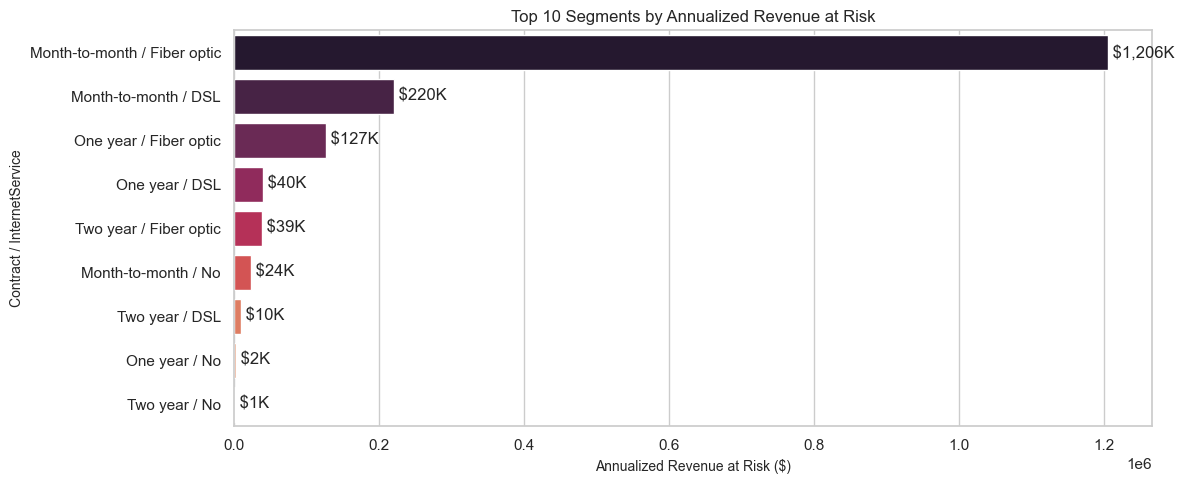

In [31]:
churners_df = analysis_df[analysis_df['Churn_Flag'] == 1]
total_customers = len(analysis_df)
churn_rate_overall = analysis_df['Churn_Flag'].mean()
mrr_total = analysis_df['MonthlyCharges'].sum()
monthly_at_risk = churners_df['MonthlyCharges'].sum()
annual_at_risk = monthly_at_risk * 12

kpi_summary = pd.DataFrame([
    {'metric': 'Total customers', 'value': f'{total_customers:,}'},
    {'metric': 'Churners', 'value': f'{len(churners_df):,} ({churn_rate_overall:.2%})'},
    {'metric': 'Total MRR', 'value': f'${mrr_total:,.0f}'},
    {'metric': 'Monthly revenue lost to churn', 'value': f'${monthly_at_risk:,.0f}'},
    {'metric': 'Annualized revenue at risk', 'value': f'${annual_at_risk:,.0f}'},
    {'metric': 'Share of MRR lost', 'value': f'{monthly_at_risk / mrr_total:.2%}'},
])
display(kpi_summary)

segment_revenue = (
    analysis_df.groupby(['Contract', 'InternetService'])
    .apply(lambda g: pd.Series({
        'customers': len(g),
        'churners': int(g['Churn_Flag'].sum()),
        'churn_rate': g['Churn_Flag'].mean(),
        'monthly_at_risk': g.loc[g['Churn_Flag'] == 1, 'MonthlyCharges'].sum(),
        'annualized_at_risk': g.loc[g['Churn_Flag'] == 1, 'MonthlyCharges'].sum() * 12,
    }))
    .reset_index()
    .sort_values('annualized_at_risk', ascending=False)
)
display(segment_revenue)

top10_revenue = segment_revenue.head(10).copy()
top10_revenue['label'] = top10_revenue['Contract'].astype(str) + ' / ' + top10_revenue['InternetService'].astype(str)

plt.figure(figsize=(12, 5))
sns.barplot(data=top10_revenue, y='label', x='annualized_at_risk', palette='rocket')
for i, val in enumerate(top10_revenue['annualized_at_risk']):
    plt.text(val, i, f' ${val/1000:,.0f}K', va='center')
plt.title('Top 10 Segments by Annualized Revenue at Risk')
plt.xlabel('Annualized Revenue at Risk ($)')
plt.ylabel('Contract / InternetService')
plt.tight_layout()
plt.show()

## 17) Histogram Grid (Numerical Distributions, Hist + KDE)

Histograms reveal binning structure and class-conditional shapes that pure KDE smooths away.

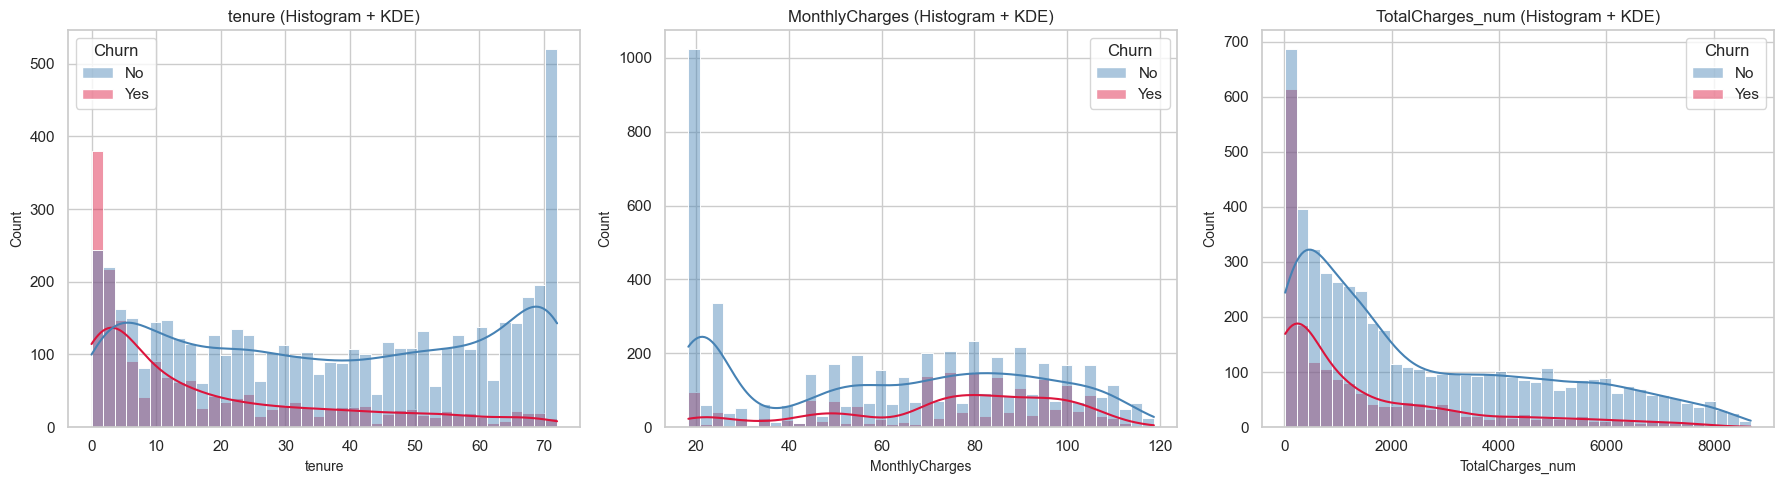

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges_num']):
    sns.histplot(
        data=df, x=col, hue='Churn',
        kde=True, multiple='layer', alpha=0.45, ax=ax, bins=40,
        palette={'Yes': 'crimson', 'No': 'steelblue'}
    )
    ax.set_title(f'{col} (Histogram + KDE)')
plt.tight_layout()
plt.show()

## 18) `PaperlessBilling` × `PaymentMethod` Cross Matrix

Billing+payment behavior is one of the highest-signal interaction pairs in telco churn. We profile the full 2-way matrix.

,PaperlessBilling,PaymentMethod,churn_rate,customers
6,Yes,Electronic check,0.497704,1742
2,No,Electronic check,0.327448,623
7,Yes,Mailed check,0.272866,656
4,Yes,Bank transfer (automatic),0.208754,891
5,Yes,Credit card (automatic),0.190476,882
3,No,Mailed check,0.134937,956
0,No,Bank transfer (automatic),0.110260,653
1,No,Credit card (automatic),0.100000,640


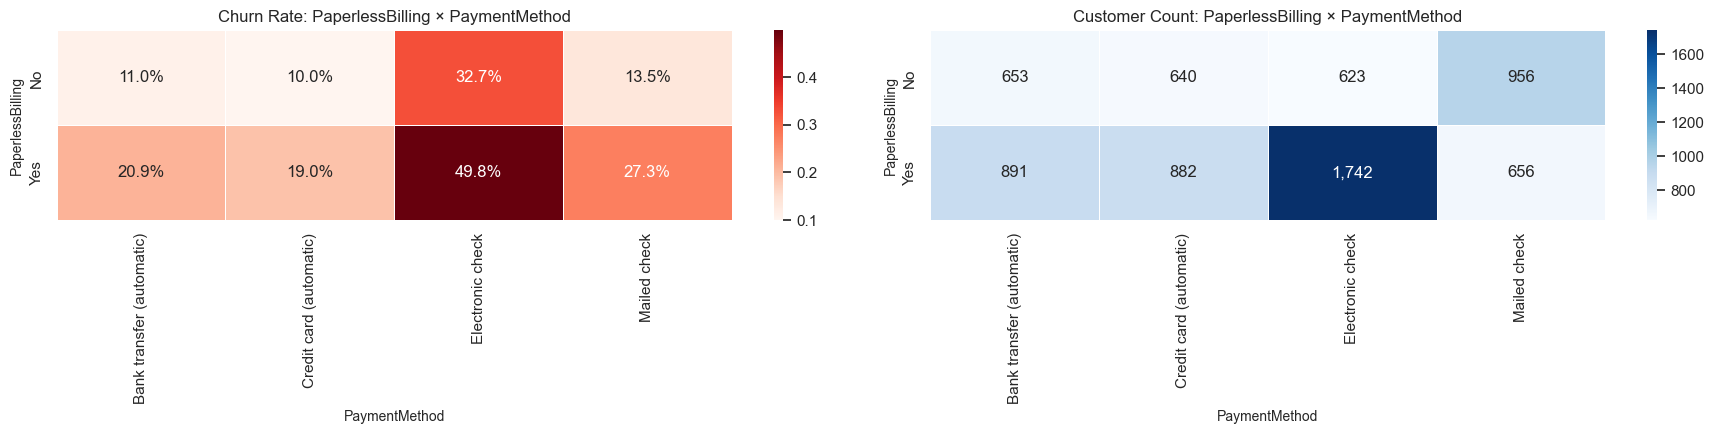

In [33]:
paperless_payment = (
    analysis_df.groupby(['PaperlessBilling', 'PaymentMethod'])['Churn_Flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
display(paperless_payment)

heat_rate = paperless_payment.pivot(index='PaperlessBilling', columns='PaymentMethod', values='churn_rate')
heat_count = paperless_payment.pivot(index='PaperlessBilling', columns='PaymentMethod', values='customers')

fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
sns.heatmap(heat_rate, annot=True, fmt='.1%', cmap='Reds', linewidths=0.5, ax=axes[0])
axes[0].set_title('Churn Rate: PaperlessBilling × PaymentMethod')
sns.heatmap(heat_count, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5, ax=axes[1])
axes[1].set_title('Customer Count: PaperlessBilling × PaymentMethod')
plt.tight_layout()
plt.show()

## 19) Distribution Percentile Tables

Quantile breakdowns at 5/25/50/75/95 percentiles per churn class — useful for setting business-meaningful thresholds (e.g., what defines a "high-charge" customer in each cohort).

In [34]:
percentile_targets = [0.05, 0.25, 0.5, 0.75, 0.95]
percentile_table = (
    df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges_num']]
    .quantile(percentile_targets)
    .round(2)
)
display(percentile_table)

ratio_table = (
    df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges_num']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)
display(ratio_table)

tenure  MonthlyCharges  TotalCharges_num
Churn                                               
No    0.05     2.0           19.60             61.06
      0.25    15.0           25.10            577.83
      0.50    38.0           64.43           1683.60
      0.75    61.0           88.40           4264.12
      0.95    72.0          108.42           7128.39
Yes   0.05     1.0           20.62             36.12
      0.25     2.0           56.15            134.50
      0.50    10.0           79.65            703.55
      0.75    29.0           94.20           2331.30
      0.95    60.0          105.61           5890.05

tenure                MonthlyCharges                        \
        mean    std min max           mean    std    min     max   
Churn                                                              
No     37.57  24.11   0  72          61.27  31.09  18.25  118.75   
Yes    17.98  19.53   1  72          74.44  24.67  18.85  118.35   

      TotalCharges_num                           
                  mean      std    min      max  
Churn                                            
No             2555.34  2329.46  18.80  8672.45  
Yes            1531.80  1890.82  18.85  8684.80

## 20) High-Risk and Low-Risk Multi-Feature Combinations

We mine 4-way categorical combinations and rank by churn rate to surface the **highest- and lowest-risk customer signatures**. We require a minimum cell size of 50 to avoid spurious cells.

Highest-risk customer signatures (n >= 50):


,Contract,InternetService,PaymentMethod,TechSupport,churn_rate,customers
12,Month-to-month,Fiber optic,Electronic check,No,0.629174,1138
14,Month-to-month,Fiber optic,Mailed check,No,0.530488,164
8,Month-to-month,Fiber optic,Bank transfer (automatic),No,0.488462,260
4,Month-to-month,DSL,Electronic check,No,0.443836,365
10,Month-to-month,Fiber optic,Credit card (automatic),No,0.440171,234
13,Month-to-month,Fiber optic,Electronic check,Yes,0.431953,169
6,Month-to-month,DSL,Mailed check,No,0.339695,262
9,Month-to-month,Fiber optic,Bank transfer (automatic),Yes,0.328358,67
11,Month-to-month,Fiber optic,Credit card (automatic),Yes,0.322034,59
33,One year,Fiber optic,Electronic check,Yes,0.285714,77



Lowest-risk customer signatures (n >= 50):


,Contract,InternetService,PaymentMethod,TechSupport,churn_rate,customers
47,Two year,DSL,Mailed check,Yes,0.000000,96
56,Two year,No,Bank transfer (automatic),No internet service,0.005618,178
59,Two year,No,Mailed check,No internet service,0.007937,252
57,Two year,No,Credit card (automatic),No internet service,0.010526,190
41,Two year,DSL,Bank transfer (automatic),Yes,0.010929,183
39,One year,No,Mailed check,No internet service,0.012195,164
37,One year,No,Credit card (automatic),No internet service,0.013158,76
43,Two year,DSL,Credit card (automatic),Yes,0.025510,196
51,Two year,Fiber optic,Credit card (automatic),Yes,0.043860,114
36,One year,No,Bank transfer (automatic),No internet service,0.044944,89


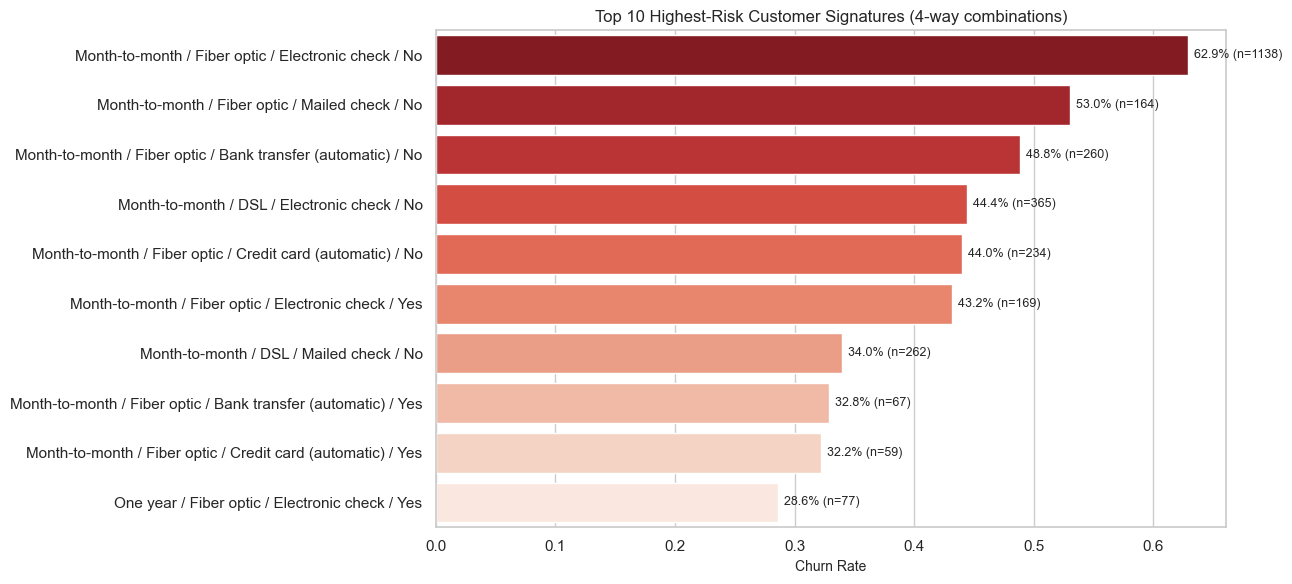

In [35]:
combo_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
combo_df = (
    analysis_df.groupby(combo_features)['Churn_Flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .reset_index()
)
combo_df = combo_df[combo_df['customers'] >= 50].sort_values('churn_rate', ascending=False)

print('Highest-risk customer signatures (n >= 50):')
display(combo_df.head(15))

print('\nLowest-risk customer signatures (n >= 50):')
display(combo_df.tail(10).iloc[::-1])

top_combo_plot = combo_df.head(10).copy()
top_combo_plot['signature'] = top_combo_plot[combo_features].astype(str).agg(' / '.join, axis=1)

plt.figure(figsize=(13, 6))
sns.barplot(data=top_combo_plot, y='signature', x='churn_rate', palette='Reds_r')
for i, (rate, n) in enumerate(zip(top_combo_plot['churn_rate'], top_combo_plot['customers'])):
    plt.text(rate + 0.005, i, f'{rate:.1%} (n={int(n)})', va='center', fontsize=9)
plt.title('Top 10 Highest-Risk Customer Signatures (4-way combinations)')
plt.xlabel('Churn Rate')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 21) Comprehensive Insights and Modeling Implications

### High-risk customer signature
- **Contract**: Month-to-month (~42.7% churn vs ~2.8% for two-year)
- **InternetService**: Fiber optic (~41.9% churn vs ~7.4% for no internet)
- **PaymentMethod**: Electronic check (~45.3% churn — clearly the highest)
- **Tenure**: First 12 months show the steepest churn slope
- **Premium services**: Customers without `TechSupport` and `OnlineSecurity` churn substantially more
- **Charges**: Higher `MonthlyCharges` with low `tenure` is the canonical churner profile
- **Demographics**: SeniorCitizens without partner/dependents are over-represented in churn cohorts

### Protective signature
- **Two-year contracts** dominate the low-risk band
- **Long tenure** (>4 years) is strongly stabilizing
- **Automatic payment methods** (bank transfer / credit card) are protective
- **Bundled premium services** (TechSupport + OnlineSecurity) reduce churn further

### Data quality decisions confirmed
- 11 `TotalCharges` blanks all align with `tenure == 0` → safe **median imputation**
- No duplicate rows or `customerID` collisions
- All categorical variables fully bounded — `OneHotEncoder(handle_unknown='ignore')` is sufficient

### Statistical evidence summary
- All major categoricals are **statistically significant** (p < 0.05) but effect sizes (Cramer's V) vary; `Contract`, `OnlineSecurity`, `TechSupport`, `InternetService` lead.
- Mann-Whitney U confirms strong distributional separation for `tenure` and `TotalCharges` between churners and stayers.

### Modeling strategy implications
- Class imbalance ~26.5% positives: track **ROC-AUC + PR-AUC**, use `class_weight='balanced'` and consider SMOTE-in-CV.
- **Threshold tuning** is mandatory — operating point should be chosen against business cost ratio.
- Engineered interactions (`Contract × Tenure`, `Paperless × AutoPay`, `Service_Count`, `Charges_Per_Service`) likely high-importance features.
- Tree-based gradient boosting expected to outperform Logistic Regression; LR retained as **interpretable baseline**.
- SHAP analysis in Phase 5 will validate these EDA-driven hypotheses.

### Business priority
- The **Month-to-month + Fiber-optic + Electronic check** segment concentrates the largest annualized revenue at risk — prioritize for retention campaigns.
- Customers in the first 12-month window are the best targets for proactive contract upgrades.